In [81]:
%pip install pymysql
%pip install mysql-connector-python pandas
%pip install SQLAlchemy
%pip install load_dotenv
%pip install pandas
%pip install matplotlib
%pip install ipython-sql
%pip install scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Set up database

In [82]:
from dotenv import load_dotenv
import os

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}", connect_args={'init_command': 'SET time_zone="+07:00"'})

# PHONE SCREEN

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sqlalchemy import create_engine, text

In [84]:
query = "SELECT * FROM minute_per_day"
df = pd.read_sql(query, engine)

In [85]:
df.head()

,DAY_ID,minutes
0,5,160.0
1,7,112.0
2,11,133.0
3,12,93.0
4,14,175.0


In [86]:
print(df[['minutes']].describe())

          minutes
count    8.000000
mean   107.750000
std     48.514357
min     38.000000
25%     82.000000
50%    107.000000
75%    139.750000
max    175.000000


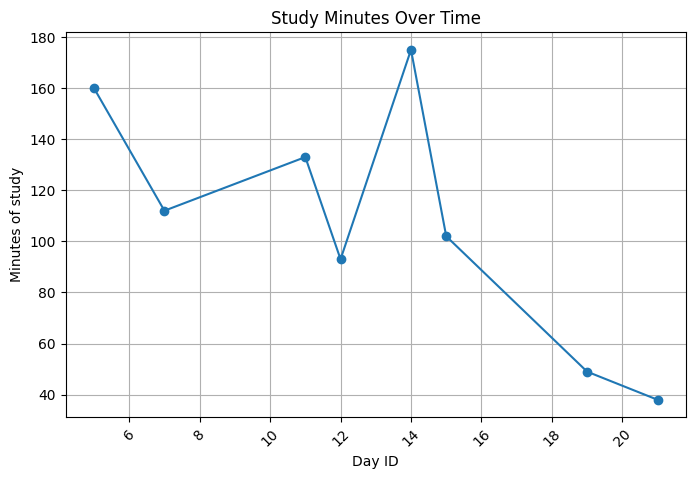

In [90]:
plt.figure(figsize=(8, 5))
plt.plot(df['DAY_ID'], df['minutes'], marker='o')
plt.xlabel('Day ID')
plt.ylabel('Minutes of study')
plt.title('Study Minutes Over Time')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [91]:
df['growth_rate (%)'] = df['minutes'].pct_change() * 100
print(df[['growth_rate (%)']].round(2))

   growth_rate (%)
0              NaN
1           -30.00
2            18.75
3           -30.08
4            88.17
5           -41.71
6           -51.96
7           -22.45


In [ ]:
initial = df['minutes'].iloc[0]
final = df['minutes'].iloc[-1]
overall_growth = ((final - initial) / initial) * 100
print(f"Overall growth rate from start to end: {overall_growth:.2f}%")

Overall growth rate from start to end: -76.25%


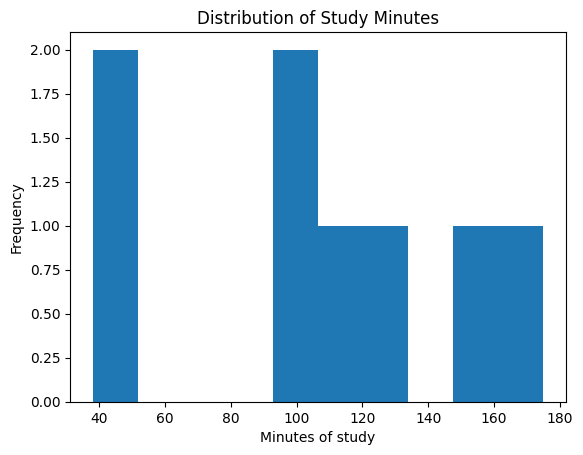

In [ ]:
df['minutes'].plot.hist()
plt.xlabel("Minutes of study")
plt.title("Distribution of Study Minutes")
plt.show()